2026-01-22 10:55:21.472603: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-22 10:55:21.655200: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 10:55:22.499443: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


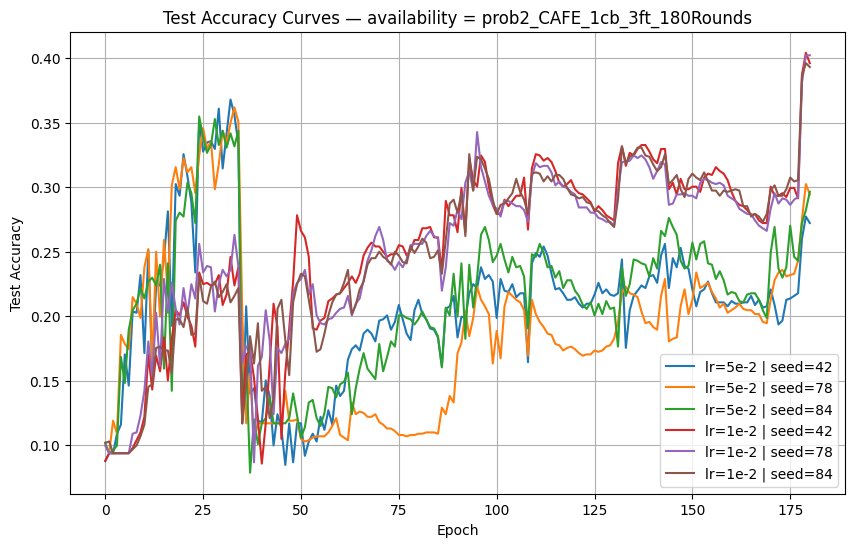

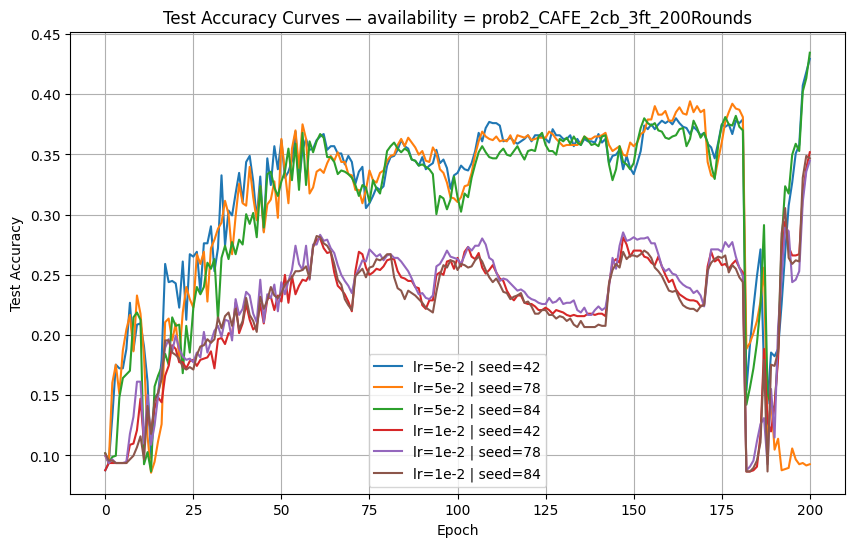

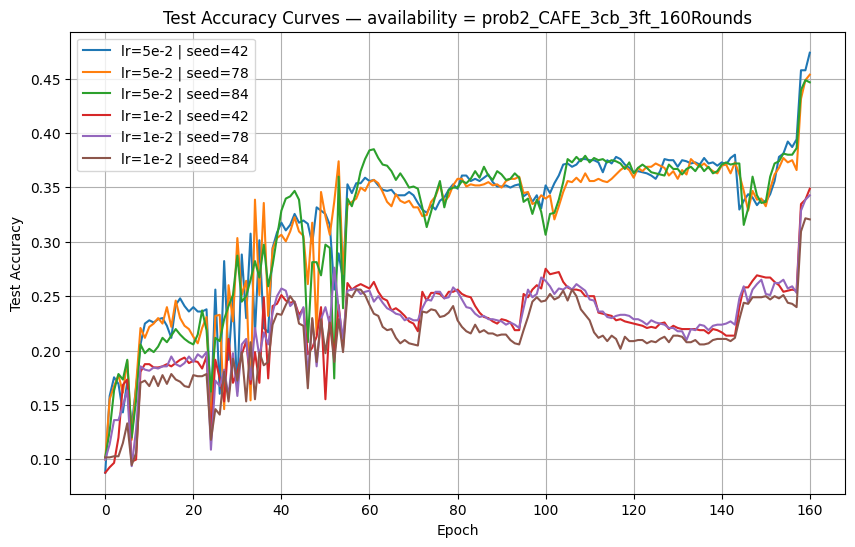

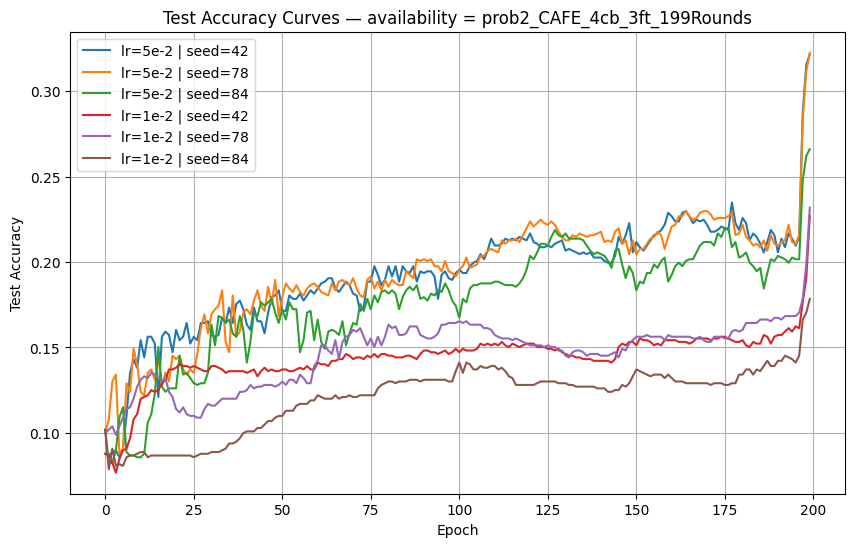

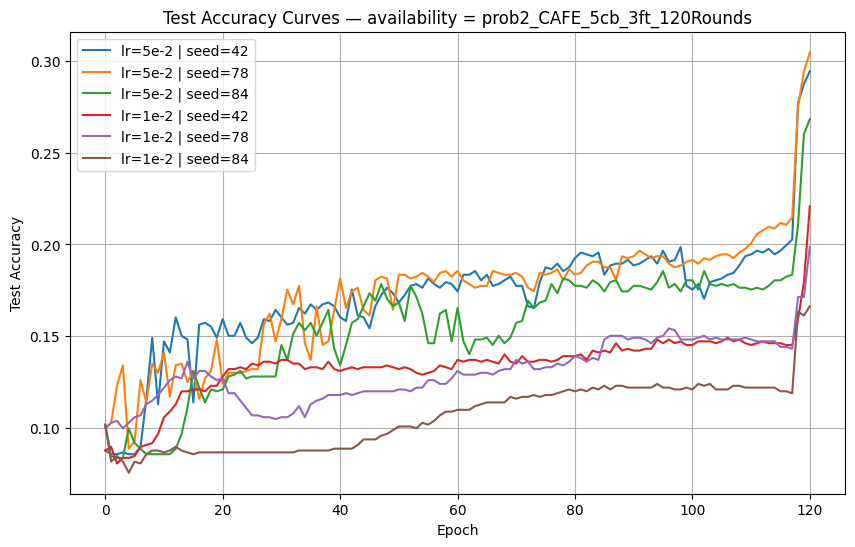

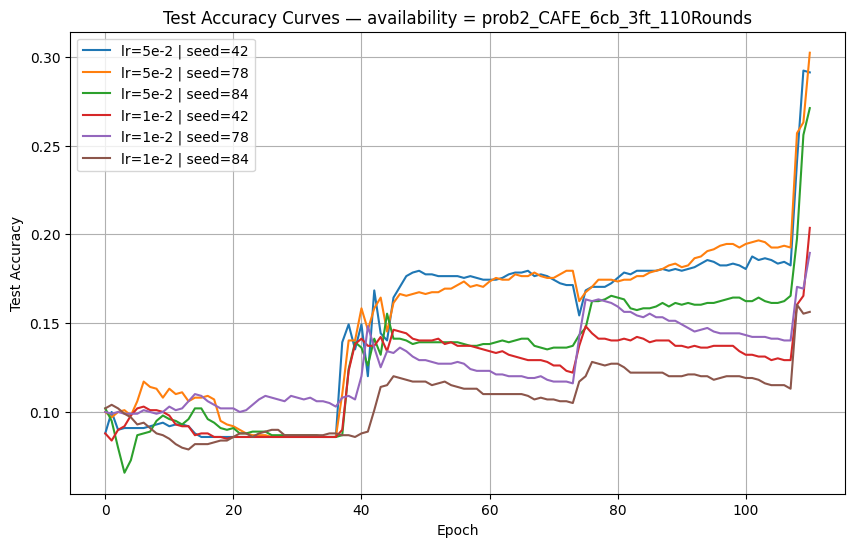

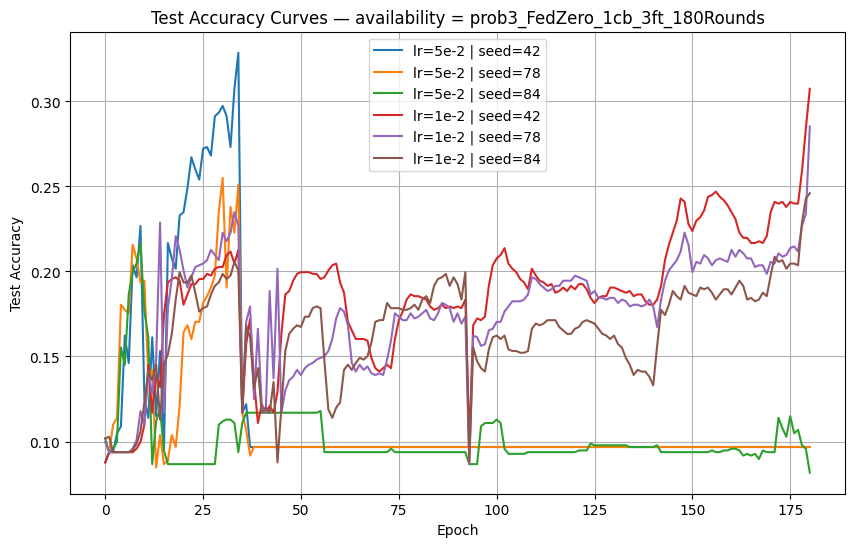

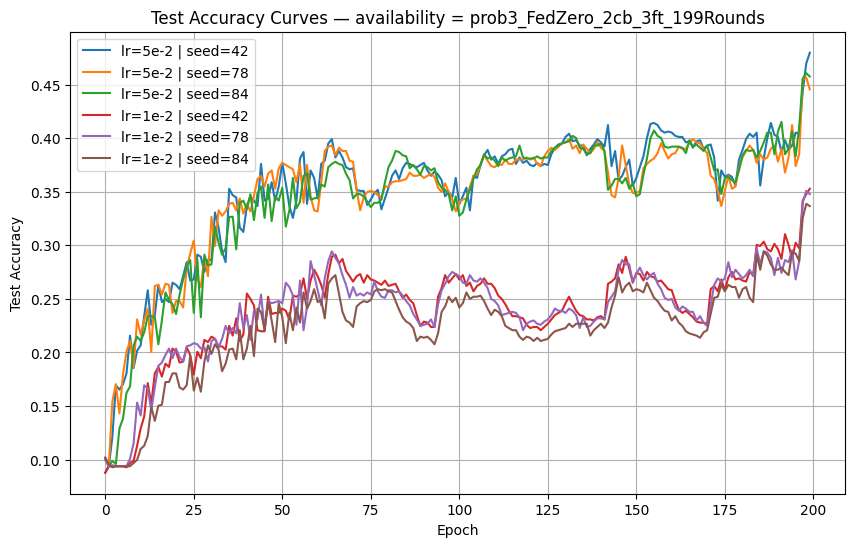

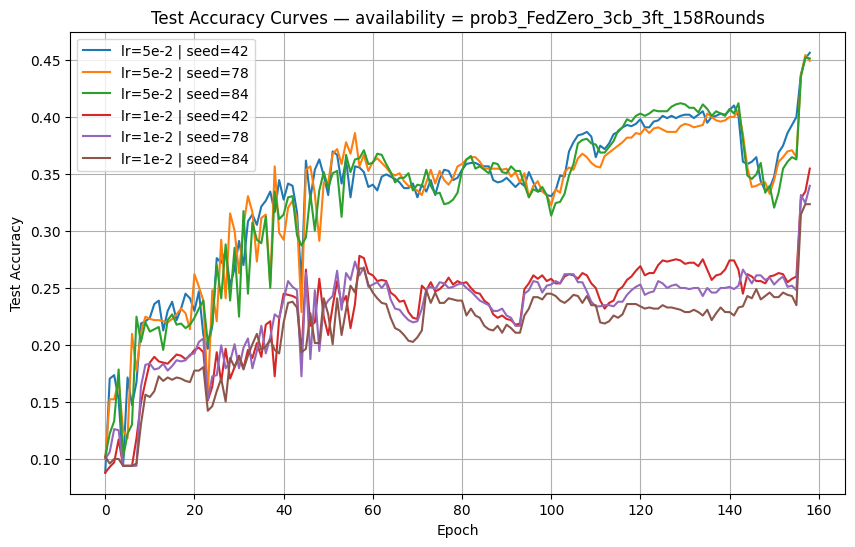

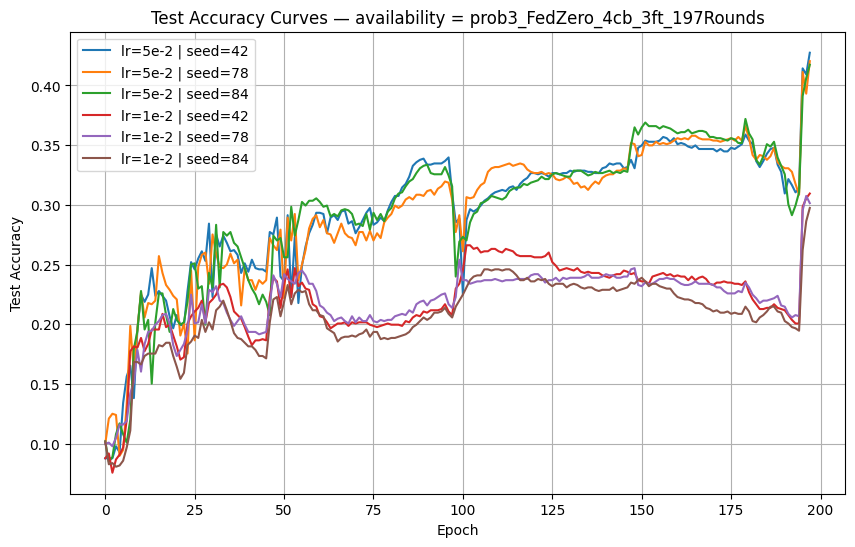

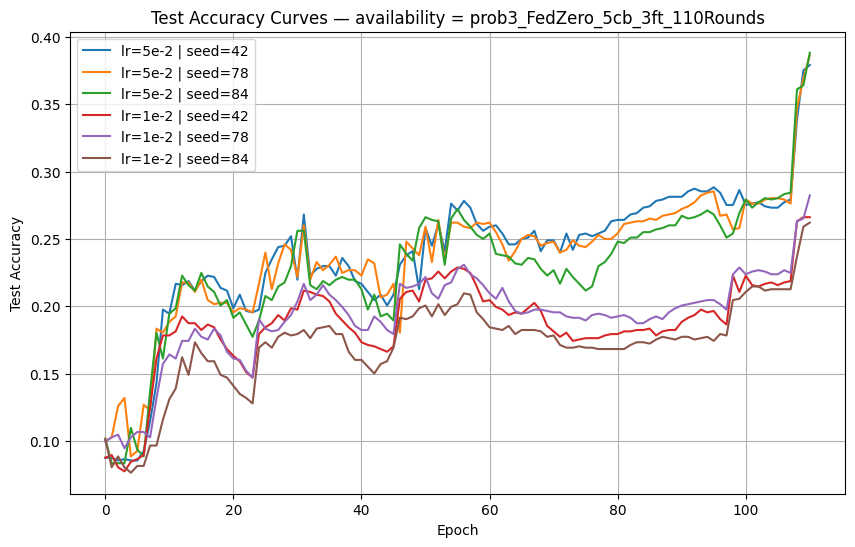

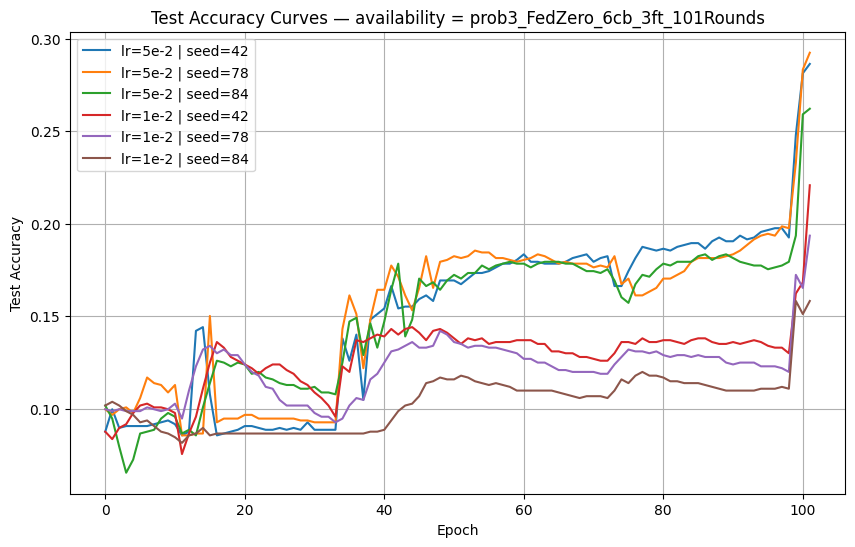

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test)
                                        # print(event_dir)
                                        # print(event_dir.split('/'))
                                        # print(os.path.exists(event_dir))

                                        if os.path.exists(event_dir):
                                            # print('helloooo')
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            # _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            # _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            # _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

main_folder = 'baselines_accuracy_check'

availabilities="""
prob2_CAFE_1cb_3ft_180Rounds 
prob2_CAFE_2cb_3ft_200Rounds 
prob2_CAFE_3cb_3ft_160Rounds 
prob2_CAFE_4cb_3ft_199Rounds 
prob2_CAFE_5cb_3ft_120Rounds 
prob2_CAFE_6cb_3ft_110Rounds 
prob3_FedZero_1cb_3ft_180Rounds 
prob3_FedZero_2cb_3ft_199Rounds 
prob3_FedZero_3cb_3ft_158Rounds 
prob3_FedZero_4cb_3ft_197Rounds 
prob3_FedZero_5cb_3ft_110Rounds 
prob3_FedZero_6cb_3ft_101Rounds 
""".split()
exp_folder="cifar_baselines_with_ft_group_notclip_bestEndFT"

config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment=exp_folder, seeds=["42", "78", "84"],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['5e-2', '1e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="200", participations=["known"], biased_list=["2"], train_test="train")

results_df = get_exp_stats(config)

results_df

# display(results_df)

import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
for availability_value, group in results_df.groupby("availability"):
    
    plt.figure(figsize=(10, 6))
    
    for _, row in group.iterrows():
        label = f"lr={row['lr']} | seed={row['seed']}"
        plt.plot(row['test_accuracy'], label=label)
    
    plt.title(f"Test Accuracy Curves — availability = {availability_value}")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [3]:
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['std_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.std(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['final_std_acc'] = tmp['std_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

In [8]:
tmp = modify_data(results_df)
tmp = tmp.loc[tmp.groupby('availability')['final_mean_acc'].idxmax()]

In [16]:

data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'_(\d+)Rounds')

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'_(\d+)cb')
fed_avg['prob_type'] = fed_avg['availability'].str.extract(r'prob(\d+)')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(50).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)
fed_avg['prob_type'] = fed_avg['prob_type'].fillna(0).astype(int)
fed_avg.sort_values(['avail_mat', "prob_type"], inplace=True)

In [23]:
fed_avg

,algorithm,availability,lr,alpha,test_accuracy,mean_test_acc,var_test_acc,std_test_acc,final_mean_acc,final_var_acc,final_std_acc,min_test_acc,max_test_acc,slack_time,avail_mat,prob_type
0,fedavg,prob2_CAFE_1cb_3ft_180Rounds,1e-2,0.5,"[[0.08770161122083664, 0.09375, 0.09375, 0.093...","[0.09643817196289699, 0.09677419314781825, 0.0...","[3.884120822015033e-05, 1.829148839062168e-05,...","[0.006232271513673834, 0.004276854964880348, 0...",0.397177,0.000014,0.003772,"[0.08770161122083664, 0.09375, 0.09375, 0.0937...","[0.10181451588869095, 0.10282257944345474, 0.0...",180,1,2
12,fedavg,prob3_FedZero_1cb_3ft_180Rounds,1e-2,0.5,"[[0.08770161122083664, 0.09375, 0.09375, 0.093...","[0.09643817196289699, 0.09677419314781825, 0.0...","[3.884120822015033e-05, 1.829148839062168e-05,...","[0.006232271513673834, 0.004276854964880348, 0...",0.279570,0.000647,0.025427,"[0.08770161122083664, 0.09375, 0.09375, 0.0937...","[0.10181451588869095, 0.10282257944345474, 0.0...",180,1,3
2,fedavg,prob2_CAFE_2cb_3ft_200Rounds,1e-2,0.5,"[[0.08770161122083664, 0.09375, 0.09375, 0.093...","[0.09643817196289699, 0.09442204236984253, 0.0...","[3.884120822015033e-05, 9.032818937271259e-07,...","[0.006232271513673834, 0.0009504114339206604, ...",0.347782,0.000009,0.002968,"[0.08770161122083664, 0.09375, 0.09375, 0.0937...","[0.10181451588869095, 0.09576612710952759, 0.0...",200,2,2
15,fedavg,prob3_FedZero_2cb_3ft_199Rounds,5e-2,0.5,"[[0.08770161122083664, 0.09375, 0.120967738330...","[0.09643817196289699, 0.09375, 0.1246639788150...","[3.884120822015033e-05, 0.0, 0.000519162259827...","[0.006232271513673834, 0.0, 0.0227851324294396...",0.461022,0.000201,0.014193,"[0.08770161122083664, 0.09375, 0.0987903252243...","[0.10181451588869095, 0.09375, 0.1542338728904...",199,2,3
5,fedavg,prob2_CAFE_3cb_3ft_160Rounds,5e-2,0.5,"[[0.08770161122083664, 0.1582661271095276, 0.1...","[0.09643817196289699, 0.14650537570317587, 0.1...","[3.884120822015033e-05, 0.00021159419085038504...","[0.006232271513673834, 0.014546277559925255, 0...",0.457997,0.000133,0.011533,"[0.08770161122083664, 0.1260080635547638, 0.16...","[0.10181451588869095, 0.1582661271095276, 0.17...",160,3,2
17,fedavg,prob3_FedZero_3cb_3ft_158Rounds,5e-2,0.5,"[[0.08770161122083664, 0.1703629046678543, 0.1...","[0.09643817196289699, 0.1481854865948359, 0.15...","[3.884120822015033e-05, 0.00039834805618567235...","[0.006232271513673834, 0.019958658677017158, 0...",0.452621,0.000009,0.002968,"[0.08770161122083664, 0.12197580933570862, 0.1...","[0.10181451588869095, 0.1703629046678543, 0.17...",158,3,3
7,fedavg,prob2_CAFE_4cb_3ft_199Rounds,5e-2,0.5,"[[0.08770161122083664, 0.08669354766607285, 0....","[0.09643817196289699, 0.0920698915918668, 0.10...","[3.884120822015033e-05, 0.00012894377740377578...","[0.006232271513673834, 0.011355341360072616, 0...",0.303427,0.000696,0.026377,"[0.08770161122083664, 0.08165322244167328, 0.0...","[0.10181451588869095, 0.10786290466785431, 0.1...",199,4,2
19,fedavg,prob3_FedZero_4cb_3ft_197Rounds,5e-2,0.5,"[[0.08770161122083664, 0.08770161122083664, 0....","[0.09643817196289699, 0.09778225670258205, 0.1...","[3.884120822015033e-05, 0.00027030756735177717...","[0.006232271513673834, 0.0164410330378531, 0.0...",0.421707,0.000018,0.004224,"[0.08770161122083664, 0.08467742055654526, 0.0...","[0.10181451588869095, 0.12096773833036423, 0.1...",197,4,3
9,fedavg,prob2_CAFE_5cb_3ft_120Rounds,5e-2,0.5,"[[0.08770161122083664, 0.08568548411130905, 0....","[0.09643817196289699, 0.09106182803710301, 0.0...","[3.884120822015033e-05, 6.932700217607588e-05,...","[0.006232271513673834, 0.008326283815489109, 0...",0.288978,0.000234,0.015295,"[0.08770161122083664, 0.08467742055654526, 0.0...","[0.10181451588869095, 0.10282257944345474, 0.1...",120,5,2
21,fedavg,prob3_FedZero_5cb_3ft_110Rounds,5e-2,0.5,"[[0.08770161122083664, 0.08770161122083664, 0....","[0.09643817196289699, 0.09139784922202428, 0.0...","[3.884120822015033e-05, 6.797207599741463e-05,...","[0.006232271513673834, 0.008244517936023587

In [26]:
left = fed_avg[fed_avg['prob_type'] == 2][['avail_mat', 'final_mean_acc', 'final_std_acc']].rename(
    columns={'final_mean_acc': 'final_mean_acc_CAFE', 'final_std_acc': 'final_std_acc_CAFE'}
)
right = fed_avg[fed_avg['prob_type'] == 3][['avail_mat', 'final_mean_acc', 'final_std_acc']].rename(
    columns={'final_mean_acc': 'final_mean_acc_FedZero', 'final_std_acc': 'final_std_acc_FedZero'}
)
joined = pd.merge(left, right, on='avail_mat', how='inner')
joined

,avail_mat,final_mean_acc_CAFE,final_std_acc_CAFE,final_mean_acc_FedZero,final_std_acc_FedZero
0,1,0.397177,0.003772,0.279570,0.025427
1,2,0.347782,0.002968,0.461022,0.014193
2,3,0.457997,0.011533,0.452621,0.002968
3,4,0.303427,0.026377,0.421707,0.004224
4,5,0.288978,0.015295,0.384409,0.003890
5,6,0.288306,0.012936,0.280242,0.013066


### To check the gradient

In [5]:
# _, test_acc_global = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/global", tag="Test/Metric")
# _, test_global_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/global", tag="Test/GradNorm")
# _, test_acc_1 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_0", tag="Test/Metric")
# _, test_1_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_0", tag="Test/GradNorm")
# _, test_acc_2 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_1", tag="Test/Metric")
# _, test_2_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_1", tag="Test/GradNorm")
# _, test_acc_3 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_2", tag="Test/Metric")
# _, test_3_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_2", tag="Test/GradNorm")
# _, test_acc_4 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_3", tag="Test/Metric")
# _, test_4_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_3", tag="Test/GradNorm")
# _, test_acc_5 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_4", tag="Test/Metric")
# _, test_5_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_4", tag="Test/GradNorm")
# _, test_acc_6 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_5", tag="Test/Metric")
# _, test_6_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_5", tag="Test/GradNorm")
# _, test_acc_7 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_6", tag="Test/Metric")
# _, test_7_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_6", tag="Test/GradNorm")

# # Create a figure with 8 subplots (one for each task, including the global one)
# fig, axs = plt.subplots(8, 1, figsize=(10, 25), sharex=True)

# # Define the data and labels for each subplot
# tasks = [
#     ("Global", test_acc_global, test_global_grad),
#     ("Task 0", test_acc_1, test_1_grad),
#     ("Task 1", test_acc_2, test_2_grad),
#     ("Task 2", test_acc_3, test_3_grad),
#     ("Task 3", test_acc_4, test_4_grad),
#     ("Task 4", test_acc_5, test_5_grad),
#     ("Task 5", test_acc_6, test_6_grad),
#     ("Task 6", test_acc_7, test_7_grad),
# ]
# print("Final Accuracy:", test_acc_global[-1])
# x_values = np.arange(201)  # This will create an array from 0 to 100 (101 data points)
# x_ticks = np.arange(0, 201, 10)  # This will create ticks every 5 epochs (0, 5, 10, ..., 100)
# # Loop through each subplot and plot the data
# for i, (task_name, acc_data, grad_data) in enumerate(tasks):
#     ax1 = axs[i]  # Select the subplot

#     # Plot accuracy on the left y-axis
#     ax1.plot(acc_data, 'r', label=f'Accuracy ({task_name})', linewidth=2)
#     ax1.set_ylabel('Accuracy', color='r')
#     ax1.tick_params(axis='y', labelcolor='r')

#     # Create the second y-axis for gradient norm
#     ax2 = ax1.twinx()
#     ax2.plot(grad_data, 'g', label=f'Grad Norm ({task_name})', linestyle='--', linewidth=2)
#     ax2.set_ylabel('Gradient Norm', color='g')
#     ax2.tick_params(axis='y', labelcolor='g')

#     # Set title for each subplot
#     ax1.set_title(f"{task_name} - Accuracy and Gradient Norm")

#     # Set the x-ticks and labels on every subplot
#     ax2.set_xticks(x_ticks)
#     ax2.set_xticklabels(x_ticks)

#     # Optional: Add legend to each subplot
#     ax1.legend(loc='upper left')
#     ax2.legend(loc='upper right')

# # Set x-axis label for the bottom subplot
# axs[-1].set_xlabel('Epochs')

# # Adjust layout to prevent overlap
# fig.tight_layout()

# # Show the plot
# plt.show()